In [87]:
import pandas as pd
import ast
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [35]:
df = pd.read_csv(r"C:\Users\kytus\Desktop\ProjecteData\Equip_25\Data\clean_data_16-03-2026.csv",parse_dates=['insert_date','first_review_date','last_review_date'])

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7537 entries, 0 to 7536
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   apartment_id                 7537 non-null   int64         
 1   name                         7534 non-null   object        
 2   description                  7537 non-null   object        
 3   host_id                      7537 non-null   int64         
 4   neighbourhood_name           7537 non-null   object        
 5   neighbourhood_district       7537 non-null   object        
 6   room_type                    7537 non-null   object        
 7   accommodates                 7537 non-null   int64         
 8   bathrooms                    7494 non-null   float64       
 9   bedrooms                     7499 non-null   float64       
 10  beds                         7530 non-null   float64       
 11  amenities_list               7537 non-null 

In [37]:

df['amenities_str'] = df['amenities_list'].astype(str)


# Quitamos llaves, corchetes y comillas
df['amenities_str'] = df['amenities_str'].str.replace(r'[\{\}\[\]\"]', '', regex=True)

# Arreglamos caracteres raros y espacios extraños
df['amenities_str'] = df['amenities_str'].str.replace('u2019', "'", regex=False)
df['amenities_str'] = df['amenities_str'].str.replace('\u00a0', ' ', regex=False)

# Unificamos los errores de escritura 
df['amenities_str'] = df['amenities_str'].str.replace(r"Children.s", "Children's", regex=True)
df['amenities_str'] = df['amenities_str'].str.replace(r"Pack .n Play", "Pack 'n Play", regex=True)
df['amenities_str'] = df['amenities_str'].str.replace('u2013', '-', regex=False)
df['amenities_str'] = df['amenities_str'].str.replace('u00a0', ' ', regex=False)

df['amenities_str'] = df['amenities_str'].str.replace('\u2013', '-', regex=False)


df['amenities_str'] = df['amenities_str'].str.replace('\u00a0', ' ', regex=False)


def extraer_y_filtrar(texto):
    if pd.isna(texto) or texto == 'nan':
        return []
    
    # Separamos por comas
    elementos = texto.split(',')
    lista_final = []
    
    for e in elementos:
        limpio = e.strip()
        # Si no está vacío y NO es un error de traducción o un sin contestar, lo guardamos
        if limpio and "translation missing" not in limpio.lower() and "(sin contestar)" not in limpio.lower():
            lista_final.append(limpio)
            
    return lista_final


# 3. APLICAMOS AL DATAFRAME PRINCIPAL 
df['amenities_final'] = df['amenities_str'].apply(extraer_y_filtrar)



todas_las_amenities = []
for lista in df['amenities_final']:
    todas_las_amenities.extend(lista)

lista_unica = sorted(list(set(todas_las_amenities)))

print(f"Se han encontrado {len(lista_unica)} amenities distintas ")

Se han encontrado 234 amenities distintas 


In [38]:
cat_accesibilidad = {
    'Accessible-height bed': 6,
    'Accessible-height toilet': 4,
    'Elevator': 4,
    'Elevator in building': 4,
    'Fixed grab bars for shower': 4,
    'Fixed grab bars for shower & toilet': 5,
    'Fixed grab bars for toilet': 4,
    'Flat': 10,
    'Flat path to front door': 7,
    'Flat path to guest entrance': 8,
    'Ground floor access': 4,
    'Mudroom': 8,
    'No stairs or steps to enter': 6,
    'Roll-in shower': 9,
    'Shower chair': 3,
    'Single level home': 7,
    'smooth pathway to front door': 8,
    'Step-free access': 6,
    'Step-free shower': 9,
    'Walk-in shower': 8,
    'Well-lit path to entrance': 7,
    'Wheelchair accessible': 5,
    'Wide clearance to bed': 8,
    'Wide clearance to shower': 7,
    'Wide clearance to shower & toilet': 6,
    'Wide doorway': 5,
    'Wide doorway to guest bathroom': 5,
    'Wide entrance': 9,
    'Wide entrance for guests': 8,
    'Wide entryway': 9,
    'Wide hallway clearance': 8,
    'Wide hallways': 8,
    'Bathtub with bath chair': 4

}

cat_wifi_oficina = {
    'Buzzer/wireless intercom': 6,
    'Dedicated workspace': 8,
    'Ethernet connection': 9,
    'Internet': 3,
    'Laptop-friendly workspace': 5,
    'Laptop friendly workspace': 6,
    'Pocket wifi': 6,
    'Printer': 7,
    'Wifi': 4,
    'Wifi - 100 Mbps': 8,
    'Wireless Internet': 4
}

cat_TV_clima = {
    '40 HDTV': 3,
    '43 HDTV with Netflix': 6,
    'Air conditioning': 7,
    'Amazon Echo': 7,
    'Bluetooth sound system': 8,
    'Cable TV': 4,
    'Ceiling fan': 4,
    'Central air conditioning': 9,
    'Central heating': 8,
    'DVD player': 1,
    'Game console': 9,
    'HBO GO': 7,
    'IKEA NEARBY Bluetooth sound system': 5,
    'Netflix': 7,
    'Portable fans': 2,
    'Smart TV': 7,
    'Sound system': 9,
    'TV': 3
}

cat_family_friendly = {
    'Baby bath': 4,
    'Baby monitor': 8,
    'Baby safety gates': 5,
    'Babysitter recommendations': 9,
    'Changing table': 7,
    "Children's books and toys": 6,
    "Children's dinnerware": 4,
    'Crib': 6,
    'Family/kid friendly': 3,
    'High chair': 5,
    'Outlet covers': 2,
    "Pack 'n Play/travel crib": 7,  
    'Pool toys': 7,
    'Stair gates': 5,
    'Table corner guards': 4  
}

cat_baños = {
    'Bath towel': 1,
    'Bathroom essentials': 1,
    'Bathtub': 4,
    'Bidet': 3,
    'Body soap': 2,
    'Conditioner': 2,
    'En suite bathroom': 10,
    'Hair dryer': 4,
    'Heated towel rack': 4,
    'Hot water': 1,
    'Rituals body soap': 6,
    'Rituals shampoo': 6,
    'Shampoo': 2,
    'Shower gel': 2,
    'Soaking tub': 9,
    'Toilet paper': 1,
    'Touchless faucets': 6,
    'Walk-in shower': 7,
    'toilet': 1
}

cat_cocina_equipada = {
    'Baking sheet': 2,
    'Bread maker': 6,
    'Breakfast table': 4,
    'Coffee maker': 4,
    'Convection oven': 7,
    'Cooking basics': 1,
    'Dining table': 4,
    'Dishes and silverware': 1,
    'Dishwasher': 8,
    'Double oven': 9,
    'Electric stove': 4,
    'Espresso machine': 6,
    'Freezer': 3,
    'Full kitchen': 7,
    'Gas oven': 4,
    'Hot water kettle': 3,
    'Kitchen': 8,
    'Kitchenette': 3,
    'Microwave': 4,
    'Mini fridge': 3,
    'Nespresso machine': 6,
    'Oven': 5,
    'Pour Over Coffee': 3,
    'Pour-over coffee': 3,
    'Refrigerator': 3,
    'Rice Maker': 4,
    'Stainless steel electric stove': 4,
    'Stainless steel oven': 5,
    'Stainless steel stove': 4,
    'Steam oven': 4,
    'Stove': 2,
    'Toaster': 3,
    'Warming drawer': 4,
    'Wine glasses': 2
}

cat_habitacion = {
    'Bed linens': 1,
    'Bedroom comforts': 1,
    'Clothing storage': 2,
    'Clothing storage: closet': 2,
    'Day bed': 7,
    'Extra pillows and blankets': 6,
    'Firm mattress': 2,
    'Hangers': 2,
    'Memory foam mattress': 7,
    'Murphy bed': 1,
    'Pillow-top mattress': 9,
    'Room-darkening shades': 5
}

cat_lujo = {
    'BBQ grill': 9,
    'Balcony': 7,
    'Barbecue utensils': 8,
    'Beach essentials': 6,
    'Beach view': 10,
    'Beachfront': 10,
    'Bluetooth sound system': 5,
    'Breakfast': 8,
    'Exercise equipment': 10,
    'Formal dining area': 8,
    'Game console': 8,
    'Garden or backyard': 10,
    'Gym': 10,
    'Hammock': 7,
    'Hot tub': 10,
    'IKEA NEARBY Bluetooth sound system': 5,
    'Lake access': 10,
    'Mountain view': 8,
    'Outdoor dining area': 9,
    'Outdoor furniture': 8,
    'Outdoor seating': 8,
    'Outdoor shower': 8,
    'Patio or balcony': 9,
    'Pool': 10,
    'Pool toys': 5,
    'Private living room': 6,
    'Rain shower': 9,
    'Shared garden or backyard': 5,
    'Shared outdoor pool': 7,
    'Shared pool': 7,
    'Ski in/Ski out': 10,
    'Ski-in/Ski-out': 10,
    'Sound system': 5,
    'Suitable for events': 9,
    'Sun loungers': 6,
    'Terrace': 8,
    'Waterfront': 10
}

cat_seguridad_logistica = {
    '24-hour check-in': 7,
    'Building staff': 9,
    'Buzzer/wireless intercom': 2,
    'Carbon monoxide alarm': 1,
    'Carbon monoxide detector': 1,
    'Doorman': 9,
    'Doorman Entry': 9,
    'EV charger': 9,
    'Fire extinguisher': 1,
    'Fireplace guards': 6,
    'First aid kit': 1,
    'Free driveway parking on premises - 1 space': 8,
    'Free parking on premises': 7,
    'Free parking on street': 6,
    'Free street parking': 6,
    'Front desk/doorperson': 9,
    'Host greets you': 2,
    'Keypad': 8,
    'Lock on bedroom door': 8,
    'Lockbox': 8,
    'Long term stays allowed': 5,
    'Luggage dropoff allowed': 7,
    'Mudroom': 7,
    'Paid parking garage off premises': 3,
    'Paid parking garage on premises': 3,
    'Paid parking off premises': 3,
    'Paid parking on premises': 3,
    'Private entrance': 10,
    'Safety card': 6,
    'Self Check-In': 8,
    'Self check-in': 8,
    'Smart lock': 8,
    'Smoke alarm': 1,
    'Smoke detector': 1,
    'Smoking allowed': 4
}

cat_limpieza_lavanderia = {
    
    'Cleaning products': 2,
    'Dryer': 9,
    'Drying rack for clothing': 3,
    'Iron': 5,
    'Laundromat nearby': 1,
    'Washer - In unit': 8
}

In [39]:
df_analisis=df[['room_type', 'price', 'accommodates', 'review_scores_location']].copy()

In [40]:

df_amenities = df[['room_type', 'amenities_list']].copy()


df_amenities['amenities_str'] = df_amenities['amenities_list'].astype(str)

# Quitamos llaves, corchetes y comillas
df_amenities['amenities_str'] = df_amenities['amenities_str'].str.replace(r'[\{\}\[\]\"]', '', regex=True)

# Arreglamos caracteres raros y espacios extraños
df_amenities['amenities_str'] = df_amenities['amenities_str'].str.replace('u2019', "'", regex=False)
df_amenities['amenities_str'] = df_amenities['amenities_str'].str.replace('\u00a0', ' ', regex=False)
df_amenities['amenities_str'] = df_amenities['amenities_str'].str.replace(r"Children.s", "Children's", regex=True)
df_amenities['amenities_str'] = df_amenities['amenities_str'].str.replace(r"Pack .n Play", "Pack 'n Play", regex=True)
df_amenities['amenities_str'] = df_amenities['amenities_str'].str.replace('u2013', '-', regex=False)
df_amenities['amenities_str'] = df_amenities['amenities_str'].str.replace('u00a0', ' ', regex=False)
df_amenities['amenities_str'] = df_amenities['amenities_str'].str.replace('\u2013', '-', regex=False)

def extraer_y_filtrar(texto):
    if pd.isna(texto) or texto == 'nan':
        return []
    
    elementos = texto.split(',')
    lista_final = []
    
    for e in elementos:
        limpio = e.strip()
        if limpio and "translation missing" not in limpio.lower() and "(sin contestar)" not in limpio.lower():
            lista_final.append(limpio)
            
    return lista_final

# Aplicamos tu función
df_amenities['amenities_final'] = df_amenities['amenities_str'].apply(extraer_y_filtrar)


def calcular_puntos(lista_del_piso, diccionario_categoria):
    puntos = 0
    for amenity in lista_del_piso:
        if amenity in diccionario_categoria:
            puntos += diccionario_categoria[amenity]
    return puntos

df_amenities['pts_accesibilidad'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_accesibilidad))
df_amenities['pts_wifi_oficina'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_wifi_oficina))
df_amenities['pts_tv_clima'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_TV_clima))
df_amenities['pts_family_friendly'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_family_friendly))
df_amenities['pts_banos'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_baños))
df_amenities['pts_cocina'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_cocina_equipada))
df_amenities['pts_habitacion'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_habitacion))
df_amenities['pts_lujo'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_lujo))
df_amenities['pts_seguridad'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_seguridad_logistica))
df_amenities['pts_lavanderia'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_limpieza_lavanderia))


columnas_puntos = [
    'pts_accesibilidad', 'pts_wifi_oficina', 'pts_tv_clima', 
    'pts_family_friendly', 'pts_banos', 'pts_cocina', 
    'pts_habitacion', 'pts_lujo', 'pts_seguridad', 'pts_lavanderia'
]

columnas_z_finales = []

for col in columnas_puntos:
    media = df_amenities.groupby('room_type')[col].transform('mean')
    std = df_amenities.groupby('room_type')[col].transform('std')
    
    nombre_z = f'z_{col}'
    df_amenities[nombre_z] = (df_amenities[col] - media) / (std + 0.0001)
    columnas_z_finales.append(nombre_z)

# Traspasamos SOLO los Z-scores a tu DataFrame original
df_analisis[columnas_z_finales] = df_amenities[columnas_z_finales]

# Comprobamos que ya no hay ceros
print(df_analisis[['room_type'] + columnas_z_finales].head())

         room_type  z_pts_accesibilidad  z_pts_wifi_oficina  z_pts_tv_clima  \
0     Private room            -0.173532            1.622359        1.258530   
1     Private room            -0.173532            1.622359        1.258530   
2  Entire home/apt             0.196359            1.611298        0.296152   
3     Private room            -0.173532            0.545464       -0.335386   
4     Private room             0.872898            0.007017       -1.018493   

   z_pts_family_friendly  z_pts_banos  z_pts_cocina  z_pts_habitacion  \
0              -0.348406     0.526540     -1.177342         -0.384146   
1              -0.348406     0.872193      1.424320          1.600832   
2               0.686327     1.826057     -0.013583          1.466433   
3              -0.348406     0.872193      1.124129         -0.384146   
4               6.369280     2.254808     -0.376831          1.600832   

   z_pts_lujo  z_pts_seguridad  z_pts_lavanderia  
0   -0.647986        -0.168962     

In [41]:
df_analisis.head()

,room_type,price,accommodates,review_scores_location,z_pts_accesibilidad,z_pts_wifi_oficina,z_pts_tv_clima,z_pts_family_friendly,z_pts_banos,z_pts_cocina,z_pts_habitacion,z_pts_lujo,z_pts_seguridad,z_pts_lavanderia
0,Private room,400.0,2,100.0,-0.173532,1.622359,1.258530,-0.348406,0.526540,-1.177342,-0.384146,-0.647986,-0.168962,0.173870
1,Private room,170.0,1,80.0,-0.173532,1.622359,1.258530,-0.348406,0.872193,1.424320,1.600832,-0.647986,1.101843,0.173870
2,Entire home/apt,990.0,4,100.0,0.196359,1.611298,0.296152,0.686327,1.826057,-0.013583,1.466433,-0.801000,-0.083593,1.777892
3,Private room,400.0,2,100.0,-0.173532,0.545464,-0.335386,-0.348406,0.872193,1.124129,-0.384146,1.301048,0.169919,0.173870
4,Private room,900.0,5,100.0,0.872898,0.007017,-1.018493,6.369280,2.254808,-0.376831,1.600832,3.708679,1.440724,2.204519


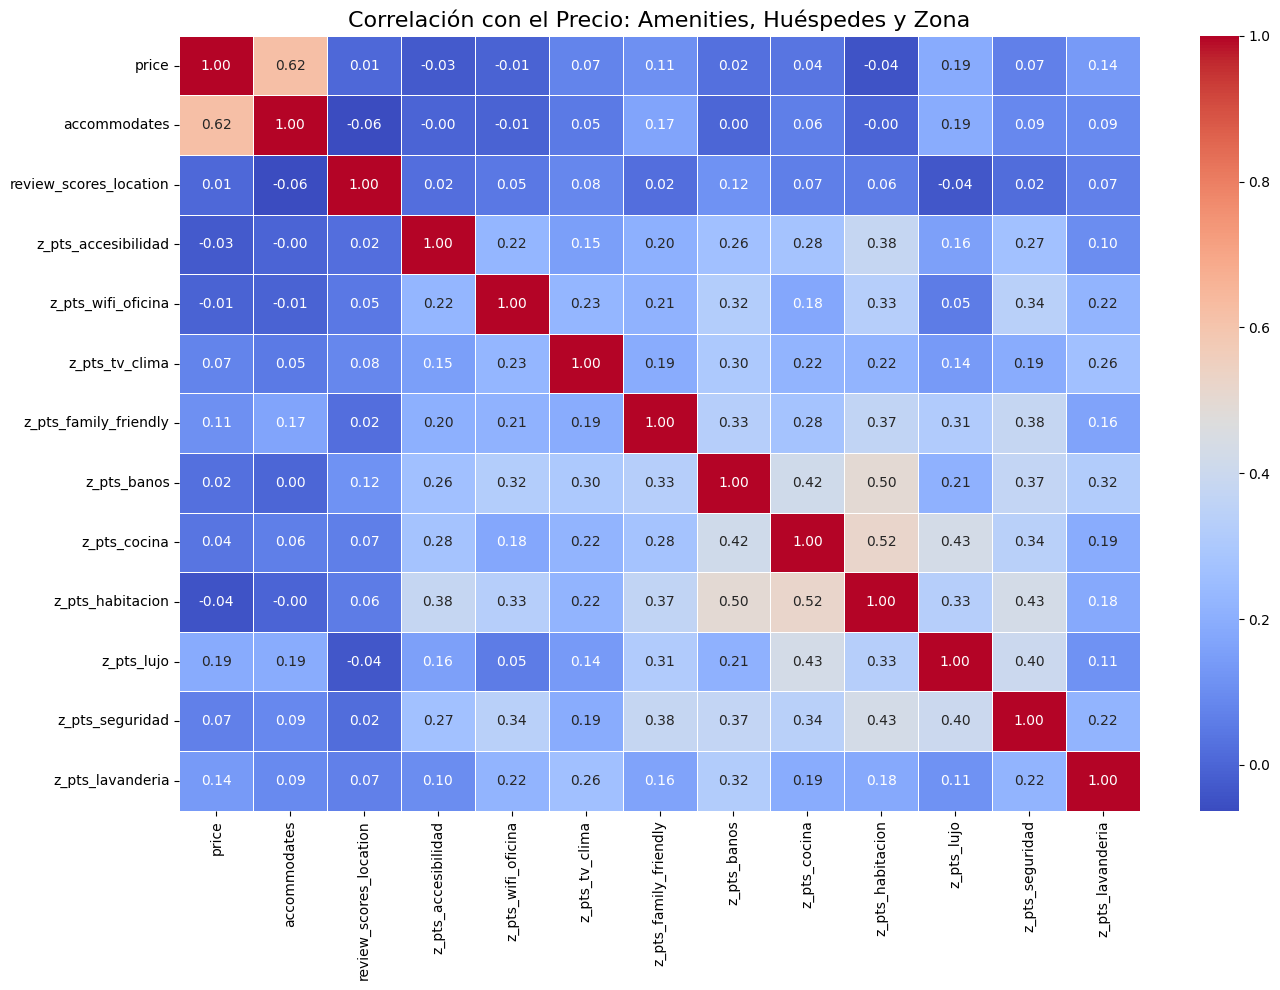

In [42]:




# 4. Limpiamos los valores nulos (NaN)
# A los modelos de ML y a las correlaciones no les gustan los huecos vacíos
df_analisis = df_analisis.dropna()




# ==============================================================================
# EL GRÁFICO PARA TU ENTREGA (Usando tu nuevo df_analisis)
# ==============================================================================

# Calculamos la correlación (le decimos numeric_only=True para que ignore el texto de 'room_type')
matriz_correlacion = df_analisis.corr(numeric_only=True)

# Dibujamos el Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(matriz_correlacion, 
            annot=True,        # Muestra el número dentro de la celda
            cmap='coolwarm',   # Azul = baja el precio, Rojo = sube el precio
            fmt=".2f",         # Redondeamos a 2 decimales
            linewidths=0.5)

plt.title('Correlación con el Precio: Amenities, Huéspedes y Zona', fontsize=16)
plt.tight_layout()
plt.show()

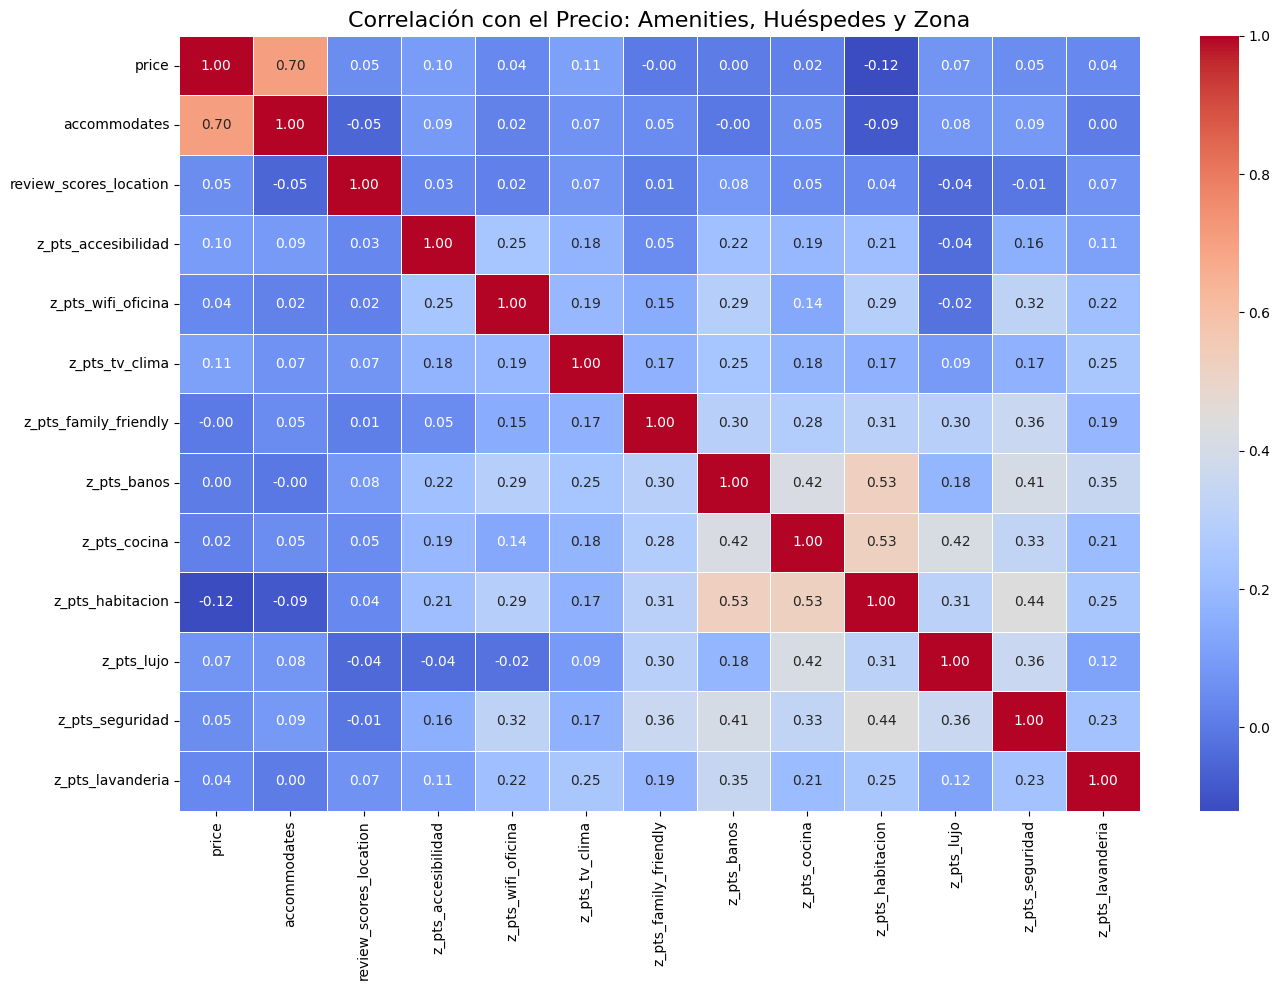

In [43]:
matriz_correlacion2 = df_analisis.corr(method='spearman', numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(matriz_correlacion2, 
            annot=True,        # Muestra el número dentro de la celda
            cmap='coolwarm',   # Azul = baja el precio, Rojo = sube el precio
            fmt=".2f",         # Redondeamos a 2 decimales
            linewidths=0.5)

plt.title('Correlación con el Precio: Amenities, Huéspedes y Zona', fontsize=16)
plt.tight_layout()
plt.show()

In [44]:
# 1. Definimos las columnas que SÍ queremos (las que te pide el ejercicio)
# Quitamos 'room_type' porque su efecto ya está en los Z-Scores
columnas_modelo = ['price', 'accommodates', 'review_scores_location'] + columnas_z_finales

# 2. Creamos un DF limpio solo con eso
df_ml = df_analisis[columnas_modelo].copy()

# 3. Separamos X e y
X = df_ml.drop('price', axis=1) # Las pistas: huéspedes, zona y los 10 z-scores
y = df_ml['price']              # El objetivo: el precio

Análisis Completado.
Error Medio (MAE): 395.26 €
Precisión (R2 Score): 0.47


C:\Users\kytus\AppData\Local\Temp\ipykernel_10012\2874672762.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Factor', data=df_imp, palette='magma')


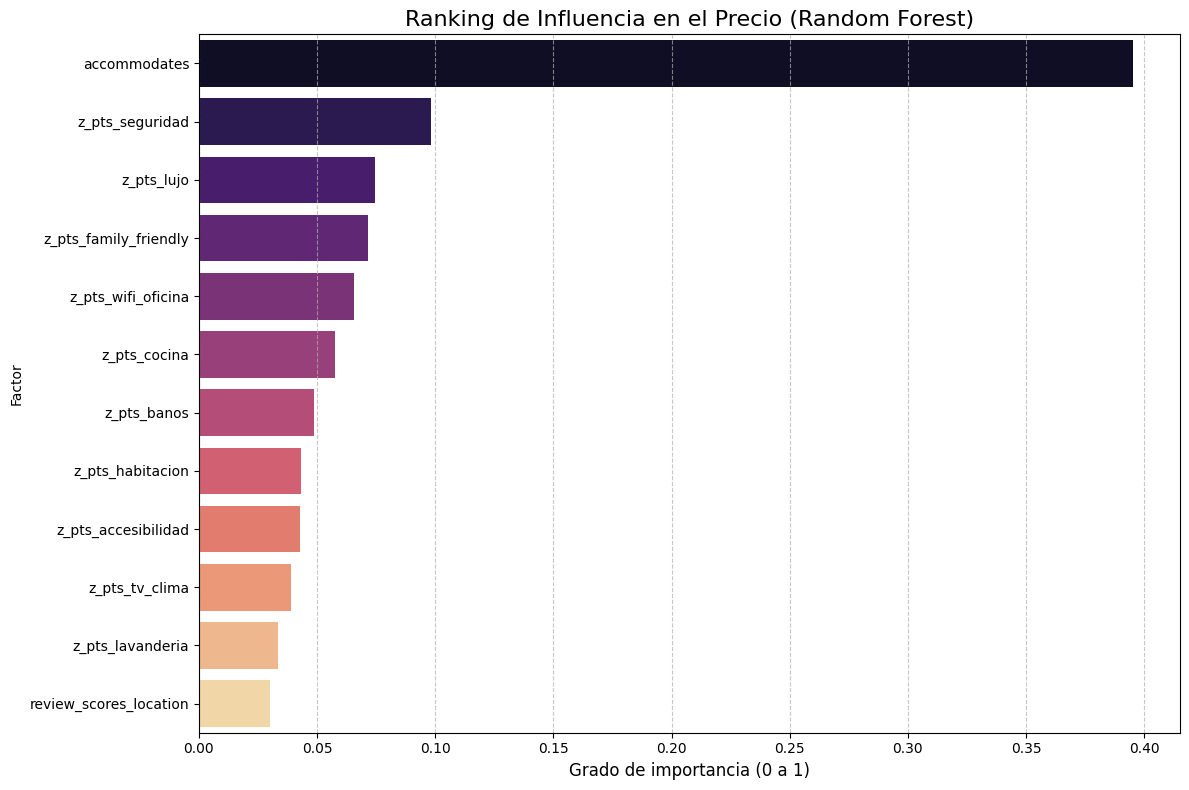

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# ==============================================================================
# 1. PREPARACIÓN DE LOS DATOS (X e y)
# ==============================================================================
# Seleccionamos solo las columnas de interés. 
# El 'room_type' no lo incluimos porque ya está "dentro" de los Z-scores.
columnas_estudio = ['price', 'accommodates', 'review_scores_location'] + columnas_z_finales
df_ml = df_analisis[columnas_estudio].copy().dropna()

# X son las "pistas" (todo menos el precio)
X = df_ml.drop('price', axis=1)
# y es el "objetivo" (el precio que queremos predecir)
y = df_ml['price']

# Dividimos: 80% para que los árboles aprendan y 20% para el examen final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# ==============================================================================
# 2. ENTRENAMIENTO DEL BOSQUE (Random Forest)
# ==============================================================================
# Plantamos 100 árboles de decisión. 
# Cada uno mirará diferentes pisos y diferentes columnas para ser variado.
modelo_rf = RandomForestRegressor(n_estimators=500, random_state=42)

# El comando .fit() es donde el bosque "estudia" las relaciones
modelo_rf.fit(X_train, y_train)

# ==============================================================================
# 3. EVALUACIÓN DEL MODELO
# ==============================================================================
# Hacemos el examen sorpresa con los datos que el modelo NO conoce (X_test)
predicciones = modelo_rf.predict(X_test)

# Calculamos el error medio (MAE) y el R2 (qué % de la variación del precio explica)
mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print(f"Análisis Completado.")
print(f"Error Medio (MAE): {mae:.2f} €")
print(f"Precisión (R2 Score): {r2:.2f}")

# ==============================================================================
# 4. EXTRACCIÓN DE RESULTADOS (Feature Importance)
# ==============================================================================
# Le preguntamos al bosque: "¿Qué columnas te han servido más para decidir el precio?"
importancias = modelo_rf.feature_importances_
df_imp = pd.DataFrame({'Factor': X.columns, 'Importancia': importancias}).sort_values(by='Importancia', ascending=False)

# Dibujamos el ranking definitivo
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Factor', data=df_imp, palette='magma')
plt.title('Ranking de Influencia en el Precio (Random Forest)', fontsize=16)
plt.xlabel('Grado de importancia (0 a 1)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [46]:
import numpy as np

# 1. Calcular el error en porcentaje (MAPE)
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test, predicciones)

print(f"El modelo se equivoca, de media, un {mape:.2f}% respecto al precio real.")

# 2. Crear una tabla de "Autopsia de Errores"
df_errores = X_test.copy()
df_errores['Precio_Real'] = y_test
df_errores['Prediccion'] = predicciones
df_errores['Error_Euros'] = df_errores['Prediccion'] - df_errores['Precio_Real']
df_errores['Error_Porcentaje'] = (abs(df_errores['Error_Euros']) / df_errores['Precio_Real']) * 100

# 3. Ver los 10 errores más grandes (donde el modelo se ha columpiado)
peores_errores = df_errores.sort_values(by='Error_Porcentaje', ascending=False).head(10)
print("\n--- LOS 10 PISOS DONDE EL MODELO MÁS SE HA EQUIVOCADO ---")
print(peores_errores[['Precio_Real', 'Prediccion', 'Error_Porcentaje', 'accommodates']])

El modelo se equivoca, de media, un 52.01% respecto al precio real.

--- LOS 10 PISOS DONDE EL MODELO MÁS SE HA EQUIVOCADO ---
      Precio_Real   Prediccion  Error_Porcentaje  accommodates
3964        100.0  1195.252000       1095.252000             6
1818        300.0  2006.933333        568.977778             4
7416        110.0   679.200000        517.454545             1
1689        120.0   708.624000        490.520000             2
1172        290.0  1685.780000        481.303448             4
3868         80.0   463.780000        479.725000             1
5613        180.0   895.600000        397.555556             4
2329        310.0  1536.560000        395.664516             2
1574        250.0  1186.520000        374.608000             4
1433        150.0   672.200000        348.133333             4


In [47]:
# 1. Definimos un límite razonable (Ajustadlo según vuestro dataset)
# Por ejemplo, filtramos pisos de más de 500€ porque suelen ser casos muy especiales
limite_precio = 500 

df_filtrado = df_analisis[df_analisis['price'] < limite_precio].copy()

print(f"Hemos pasado de {len(df_analisis)} a {len(df_filtrado)} pisos.")

# 2. Preparamos X e y con los datos limpios
columnas_estudio = ['price', 'accommodates', 'review_scores_location'] + columnas_z_finales
X_clean = df_filtrado.drop(['price','room_type'], axis=1)
y_clean = df_filtrado['price']

# 3. Dividimos y entrenamos de nuevo
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.20, random_state=42)

# Usamos 500 árboles como hiciste tú, que ya vimos que era estable
modelo_final = RandomForestRegressor(n_estimators=500, random_state=42)
modelo_final.fit(X_train_c, y_train_c)

# 4. Calculamos el nuevo error (MAPE)
pred_c = modelo_final.predict(X_test_c)
mape_nuevo = np.mean(np.abs((y_test_c - pred_c) / y_test_c)) * 100

print(f"NUEVO ERROR (MAPE): {mape_nuevo:.2f}%")

Hemos pasado de 5949 a 1725 pisos.
NUEVO ERROR (MAPE): 26.85%


C:\Users\kytus\AppData\Local\Temp\ipykernel_10012\612539891.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Factor', data=df_ranking_limpio, palette='magma')


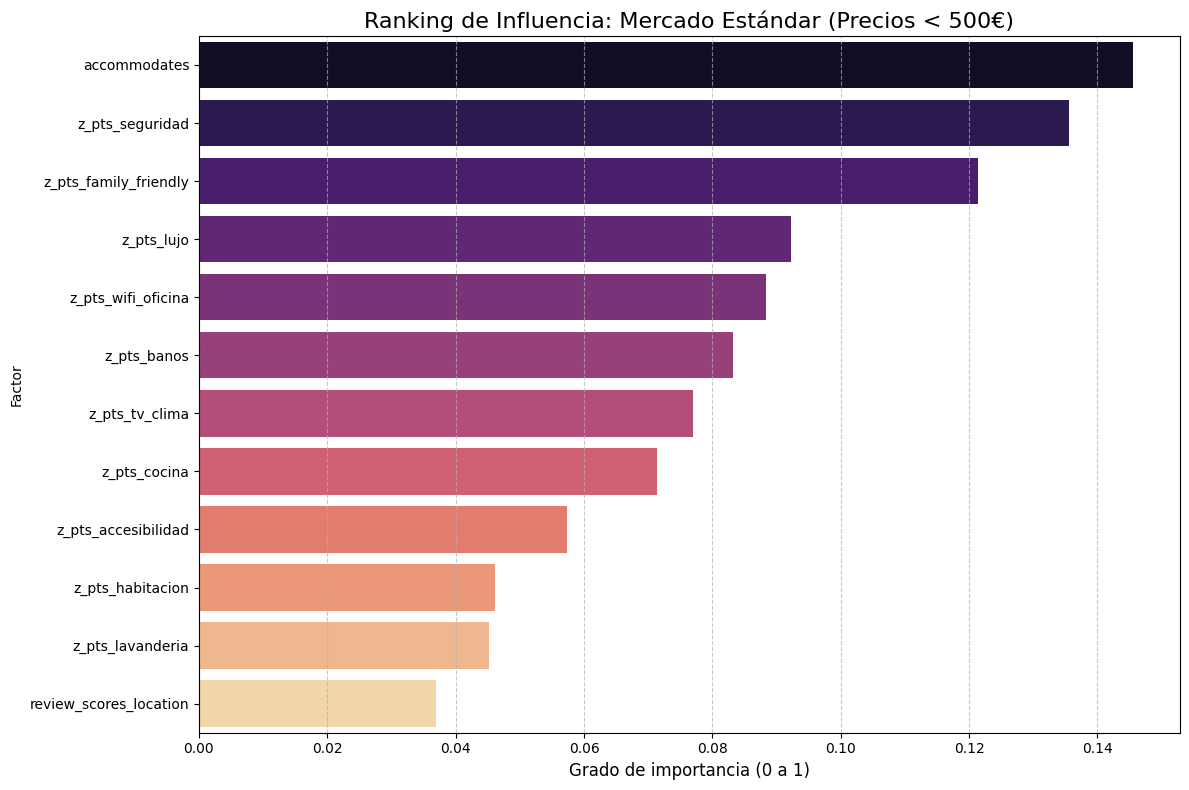

--- TOP 5 FACTORES QUE MÁS INFLUYEN EN EL PRECIO REAL ---
                   Factor  Importancia
0            accommodates     0.145577
10        z_pts_seguridad     0.135596
5   z_pts_family_friendly     0.121324
9              z_pts_lujo     0.092204
3      z_pts_wifi_oficina     0.088289


In [48]:
# 1. Extraemos las importancias del modelo "limpio"
importancias_final = modelo_final.feature_importances_
nombres_columnas = X_clean.columns

# 2. Creamos el DataFrame para organizar el ranking
df_ranking_limpio = pd.DataFrame({
    'Factor': nombres_columnas,
    'Importancia': importancias_final
}).sort_values(by='Importancia', ascending=False)

# 3. Dibujamos el gráfico con el mismo estilo que los anteriores
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Factor', data=df_ranking_limpio, palette='magma')

plt.title('Ranking de Influencia: Mercado Estándar (Precios < 500€)', fontsize=16)
plt.xlabel('Grado de importancia (0 a 1)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Guardar el resultado
plt.savefig('ranking_final_mercado_estandar.png')
plt.show()

# Mostramos también el Top 5 por texto para analizarlo
print("--- TOP 5 FACTORES QUE MÁS INFLUYEN EN EL PRECIO REAL ---")
print(df_ranking_limpio.head(5))

Segmentos: Bajo (hasta 280.00€), Medio (hasta 390.00€), Alto (más de 390.00€)


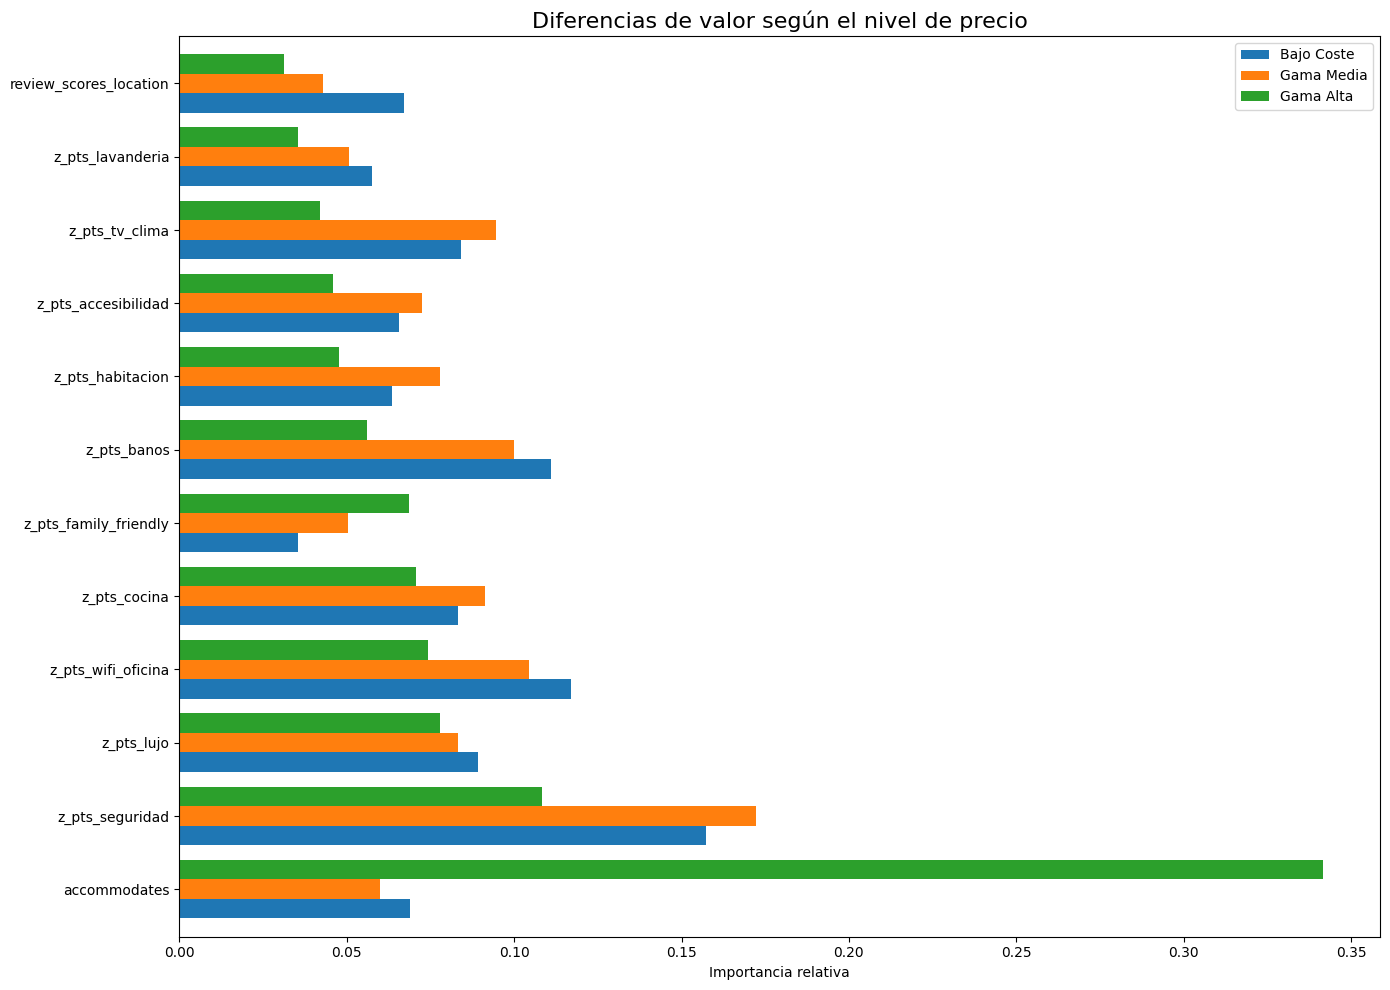

In [49]:
import numpy as np

# 1. Calculamos los cortes de precio (terciles)
cortes = df_filtrado['price'].quantile([0.33, 0.66]).values
print(f"Segmentos: Bajo (hasta {cortes[0]:.2f}€), Medio (hasta {cortes[1]:.2f}€), Alto (más de {cortes[1]:.2f}€)")

# 2. Función para entrenar un modelo rápido y devolver las importancias
def obtener_importancias_segmento(data):
    X_seg = data.drop(['price', 'room_type'], axis=1)
    y_seg = data['price']
    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X_seg, y_seg)
    return pd.Series(rf.feature_importances_, index=X_seg.columns)

# 3. Aplicamos el modelo a cada segmento
bajo = df_analisis[df_analisis['price'] <= cortes[0]]
medio = df_analisis[(df_analisis['price'] > cortes[0]) & (df_analisis['price'] <= cortes[1])]
alto = df_analisis[df_analisis['price'] > cortes[1]]

imp_bajo = obtener_importancias_segmento(bajo)
imp_medio = obtener_importancias_segmento(medio)
imp_alto = obtener_importancias_segmento(alto)

# 4. Juntamos todo para comparar
comparativa = pd.DataFrame({
    'Bajo Coste': imp_bajo,
    'Gama Media': imp_medio,
    'Gama Alta': imp_alto
}).sort_values(by='Gama Alta', ascending=False)

# 5. Visualización
comparativa.plot(kind='barh', figsize=(14, 10), width=0.8)
plt.title('Diferencias de valor según el nivel de precio', fontsize=16)
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

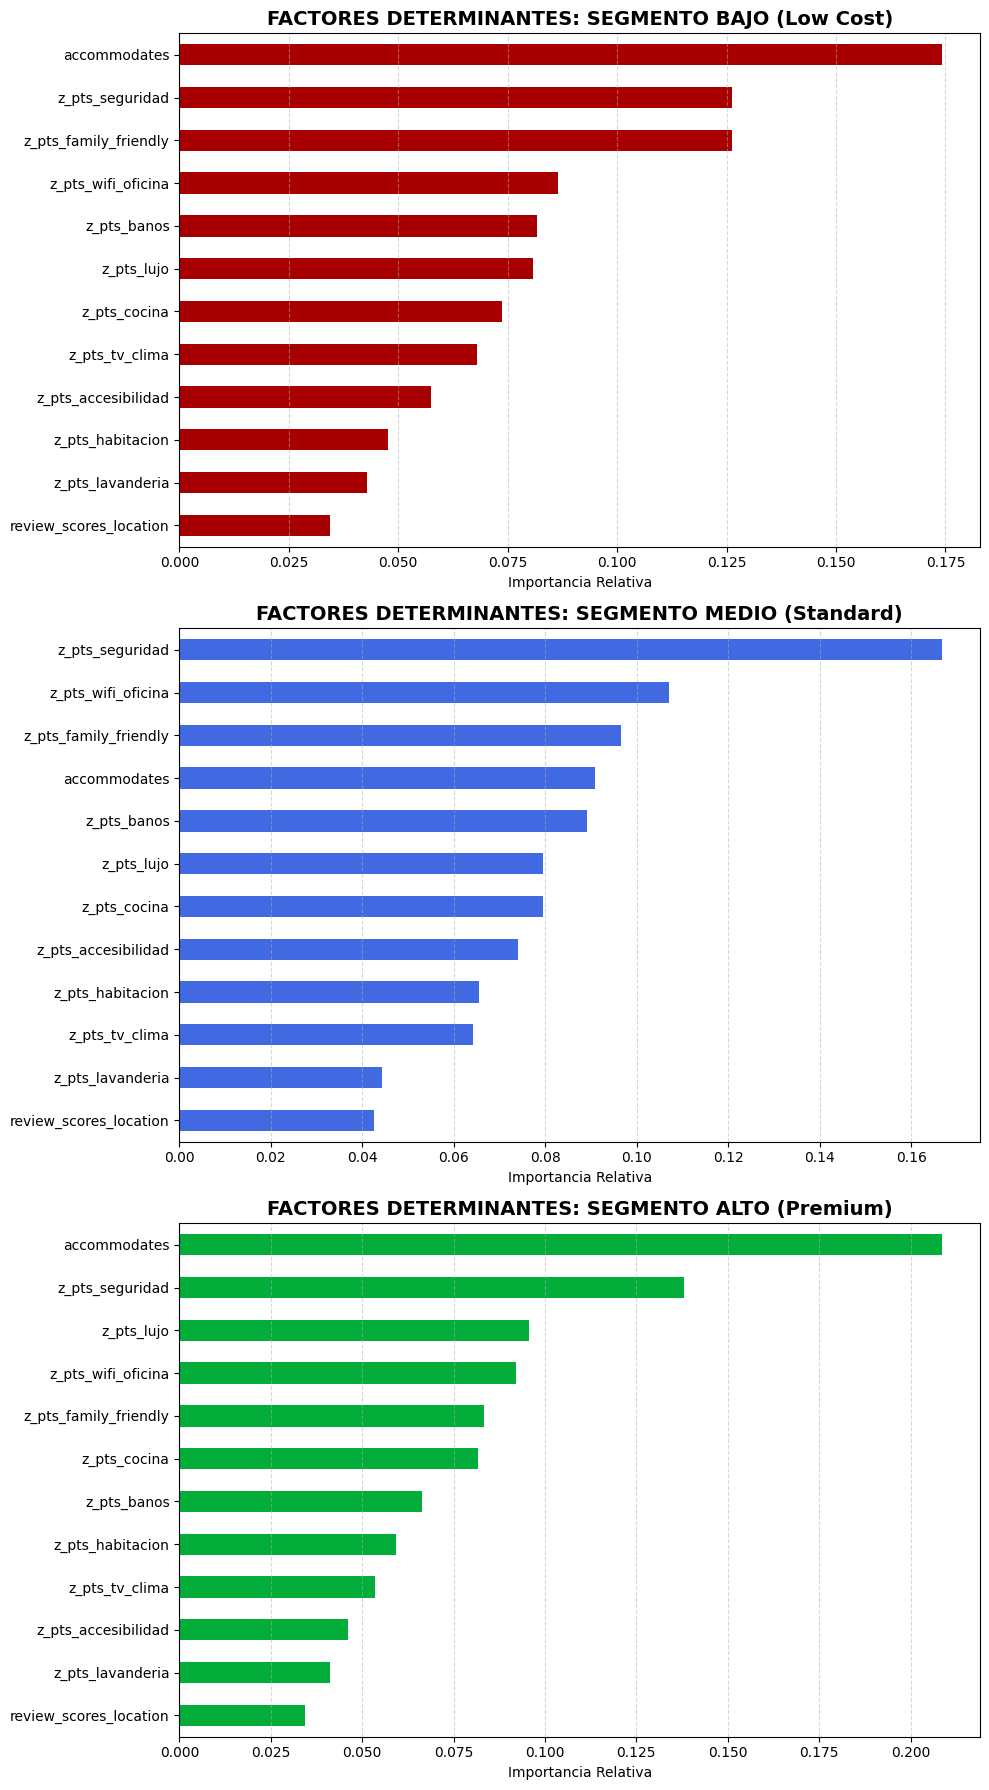

In [50]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Definimos los segmentos de precio (Cortes por terciles)
# Esto crea la lógica para filtrar el DataFrame en el bucle
cortes = df_analisis['price'].quantile([0.33, 0.66]).values

# 2. Definimos los diccionarios para el bucle (Nombre gráfico : Filtro de datos)
# Nota: Aquí la variable objetivo 'y' siempre será 'price', pero sobre subconjuntos de datos
analisis_segmentos = {
    'SEGMENTO BAJO (Low Cost)': df_analisis[df_analisis['price'] <= cortes[0]],
    'SEGMENTO MEDIO (Standard)': df_analisis[(df_analisis['price'] > cortes[0]) & (df_analisis['price'] <= cortes[1])],
    'SEGMENTO ALTO (Premium)': df_analisis[df_analisis['price'] > cortes[1]]
}

# 3. Definimos las variables independientes (X)
# Incluimos capacidad, localización y todas tus categorías de Z-scores
X_cols = [
    'accommodates', 'review_scores_location', 'z_pts_accesibilidad', 
    'z_pts_wifi_oficina', 'z_pts_tv_clima', 'z_pts_family_friendly', 
    'z_pts_banos', 'z_pts_cocina', 'z_pts_habitacion', 
    'z_pts_lujo', 'z_pts_seguridad', 'z_pts_lavanderia'
]

# 4. Configuración del lienzo (3 filas, 1 columna para que se vean bien las 12 variables)
fig, axes = plt.subplots(3, 1, figsize=(10, 18))
axes = axes.flatten()

# Colores corporativos para cada segmento
colores_graficos = ['#A80000', '#4169E1', '#02AD3A'] # Rojo, Azul, Verde

for i, (nombre_grafico, df_segmento) in enumerate(analisis_segmentos.items()):
    # Limpiamos nulos e infinitos específicos de este segmento
    df_temp = df_segmento.replace([np.inf, -np.inf], np.nan).dropna(subset=X_cols + ['price'])
    
    if len(df_temp) > 10: # Verificamos que haya datos suficientes
        X = df_temp[X_cols]
        y = df_temp['price']
        
        # Entrenamos el Random Forest para este segmento específico
        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X, y)
        
        # Extraemos y ordenamos importancias
        importances = pd.Series(rf.feature_importances_, index=X_cols).sort_values(ascending=True)
        
        # Graficamos
        importances.plot(kind='barh', ax=axes[i], color=colores_graficos[i])
        axes[i].set_title(f'FACTORES DETERMINANTES: {nombre_grafico}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Importancia Relativa')
        axes[i].grid(axis='x', linestyle='--', alpha=0.5)
    else:
        axes[i].set_title(f'{nombre_grafico} (Sin datos suficientes)', fontsize=14)

plt.tight_layout()
plt.show()

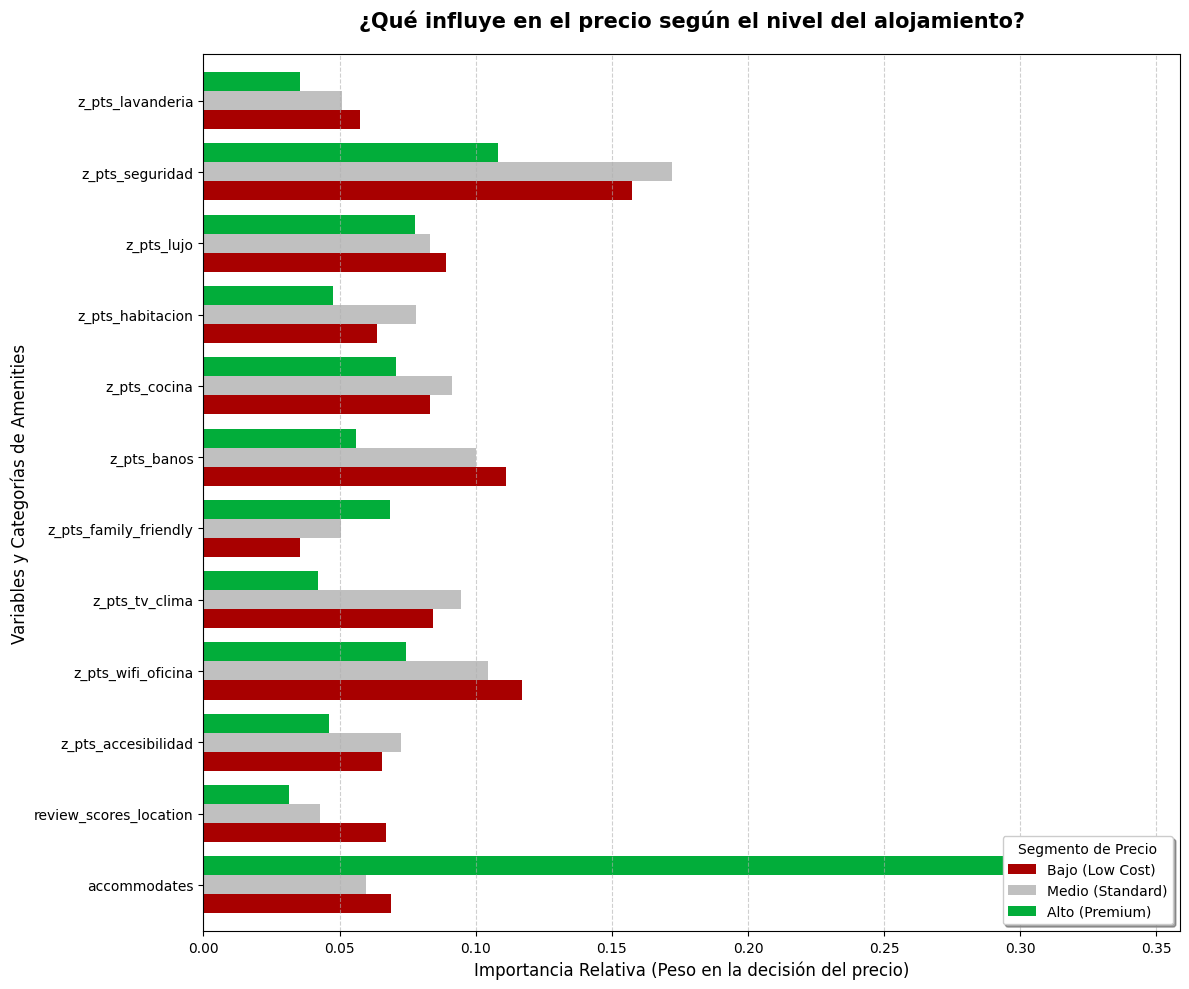

R-cuadrado Global del Random Forest: 0.4655
Interpretación: El modelo explica el 46.55% de la variación del precio.


In [51]:
# 4. Consolidar resultados para graficar (Transponemos para que las variables sean el eje Y)
df_imp_grafico = pd.DataFrame({
    'Bajo (Low Cost)': imp_bajo,
    'Medio (Standard)': imp_medio,
    'Alto (Premium)': imp_alto
}) # Aquí NO usamos .T para que las variables sean las filas

# 5. Generar el gráfico comparativo horizontal
# Usamos tus colores corporativos para los segmentos
colores_segmentos = ['#A80000', '#C0C0C0', '#02AD3A'] # Rojo para Bajo, Gris para Medio, Verde para Alto

ax = df_imp_grafico.plot(kind='barh', figsize=(12, 10), color=colores_segmentos, width=0.8)

# Configuración estética
plt.title('¿Qué influye en el precio según el nivel del alojamiento?', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Importancia Relativa (Peso en la decisión del precio)', fontsize=12)
plt.ylabel('Variables y Categorías de Amenities', fontsize=12)

# Colocamos la leyenda indicando los segmentos de precio
plt.legend(title="Segmento de Precio", labels=['Bajo (Low Cost)', 'Medio (Standard)', 'Alto (Premium)'], 
           loc='lower right', frameon=True, shadow=True)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

# 6. Modelo Global y R2
print(f"R-cuadrado Global del Random Forest: {r2:.4f}")
print(f"Interpretación: El modelo explica el {r2*100:.2f}% de la variación del precio.")

In [56]:
df_analisis_city = df_analisis

In [ ]:
# 1. Traemos la ciudad del df original usando el índice para que coincidan perfectamente
df_analisis_city['city'] = df['city']

In [61]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

# 1. Definimos las ciudades y las variables
ciudades = df_analisis_city['city'].unique()
variables_amenities = [
    'accommodates', 'review_scores_location', 'z_pts_accesibilidad', 
    'z_pts_wifi_oficina', 'z_pts_tv_clima', 'z_pts_family_friendly', 
    'z_pts_banos', 'z_pts_cocina', 'z_pts_habitacion', 
    'z_pts_lujo', 'z_pts_seguridad', 'z_pts_lavanderia'
]

resultados_lista = []

# 2. Bucle para calcular importancia por ciudad
for ciudad in ciudades:
    df_c = df_analisis_city[df_analisis_city['city'] == ciudad].dropna(subset=variables_amenities + ['price'])
    
    if len(df_c) > 30: # Filtro mínimo de datos para que el modelo sea fiable
        X = df_c[variables_amenities]
        y = df_c['price']
        
        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X, y)
        
        # Guardamos los resultados
        for var, imp in zip(variables_amenities, rf.feature_importances_):
            resultados_lista.append({
                'Ciudad': ciudad,
                'Categoria': var.replace('z_pts_', '').upper(),
                'Importancia': imp
            })

# 3. Convertimos a DataFrame
df_burbujas = pd.DataFrame(resultados_lista)
df_burbujas.to_csv('categorias_ciudades.csv')
print(df_burbujas)

     Ciudad               Categoria  Importancia
0    Malaga            ACCOMMODATES     0.264088
1    Malaga  REVIEW_SCORES_LOCATION     0.026174
2    Malaga           ACCESIBILIDAD     0.040981
3    Malaga            WIFI_OFICINA     0.063087
4    Malaga                TV_CLIMA     0.170424
..      ...                     ...          ...
91  Menorca                  COCINA     0.024653
92  Menorca              HABITACION     0.033256
93  Menorca                    LUJO     0.028452
94  Menorca               SEGURIDAD     0.132031
95  Menorca              LAVANDERIA     0.021779

[96 rows x 3 columns]


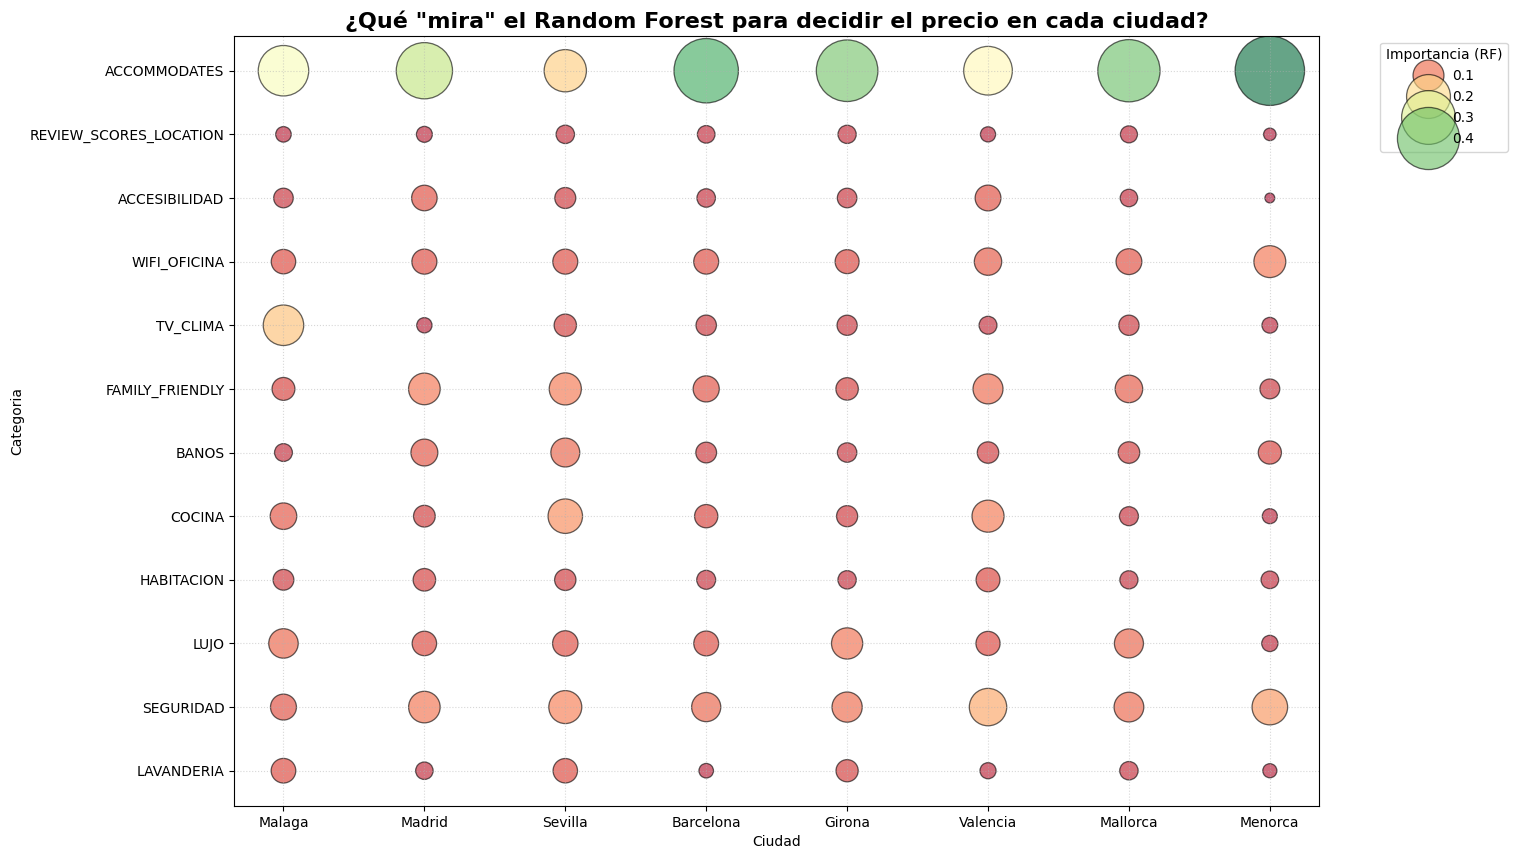

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

# El tamaño (size) de la burbuja es el 'Peso_RF'
sns.scatterplot(
    data=df_burbujas,
    x='Ciudad',
    y='Categoria',
    size='Importancia',      # <--- AQUÍ entra el resultado del Random Forest
    hue='Importancia',      # El color también cambia según la importancia
    palette='RdYlGn',   # De Rojo (NOK) a Verde (OK)
    sizes=(50, 2500),   # Ajustamos el rango de tamaños para que sea visual
    alpha=0.6,
    edgecolor='black'
)

plt.title('¿Qué "mira" el Random Forest para decidir el precio en cada ciudad?', fontsize=16, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(title='Importancia (RF)', bbox_to_anchor=(1.05, 1))
plt.show()

In [83]:
# Creamos la columna global promediando los Z-scores individuales
df_analisis['z_amenities_global'] = df_analisis[columnas_z_finales].mean(axis=1)

In [84]:
# borrar nulos review location
df_analisis.dropna(subset=['review_scores_location'], inplace=True)

In [85]:
# Seleccionar las variables independientes (X) y la variable dependiente (y).
X = df_analisis[['accommodates','review_scores_location','z_pts_accesibilidad', 'z_pts_wifi_oficina',	'z_pts_tv_clima','z_pts_family_friendly','z_pts_banos','z_pts_cocina','z_pts_habitacion','z_pts_lujo',	'z_pts_seguridad','z_pts_lavanderia']]
y = df_analisis['price']

# Dividimos los datos entre entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [86]:
# Crear y entrenar el modelo
modelo_RL = LinearRegression().fit(X_train, y_train)
modelo_RF = RandomForestClassifier().fit(X_train, y_train)


NameError: name 'LinearRegression' is not defined

In [ ]:
# Hacer predicciones sobre el conjunto de prueba
y_pred = modelo_RL.predict(X_test)
y_predRF = modelo_RF.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R-cuadrado:", r2)

R-cuadrado: 0.4367263434366869


In [ ]:
# Calcular el error cuadrático medio
mse = mean_squared_error(y_test, y_pred)
print("Error cuadrático medio:", mse)

Error cuadrático medio: 415832.1003521794


In [ ]:
# Imprimir los coeficientes y el sesgo - para ver si la tendencia de toma de decisiones son ponco exactas
print("Coeficientes:", modelo_RL.coef_)
print("Sesgo (Coeficiente W0:", modelo_RL.intercept_)
print("Coeficiente W1:", modelo_RL.coef_[0])
print("Coeficiente W2:", modelo_RL.coef_[1])

# Imprimir el coeficientes de determinación
print("Coeficiente de determinación:", modelo_RL.score(X_train, y_train))

Coeficientes: [190.95465736   3.94648767  -7.73398441   2.85094068  17.2094497
   1.61626497  18.40687782 -22.98893043 -64.11470058  84.41561057
  -2.94776872  68.27830979]
Sesgo (Coeficiente W0: -221.28671351333105
Coeficiente W1: 190.95465735730878
Coeficiente W2: 3.946487666803076
Coeficiente de determinación: 0.39707154728351524


## Modelos con solo 3 variables

In [ ]:
# Seleccionar las variables independientes (X) y la variable dependiente (y).
XX = df_analisis[['accommodates','review_scores_location','z_amenities_global']]
yy = df_analisis['price']

# Dividimos los datos entre entrenamiento y prueba
XX_train, XX_test, yy_train, yy_test = train_test_split(XX, yy, train_size=0.8, random_state=42)

In [88]:
# Crear y entrenar el modelo
modelo_Lineal = LinearRegression().fit(XX_train, yy_train)
modelo_Forest = RandomForestClassifier().fit(XX_train, yy_train)

In [ ]:
# Comapramos predicciones de valore sreales y prueba
accuracy = accuracy_score(yy_test, y_predForest)
print("Accuracy:", accuracy)

Accuracy: 0.025210084033613446


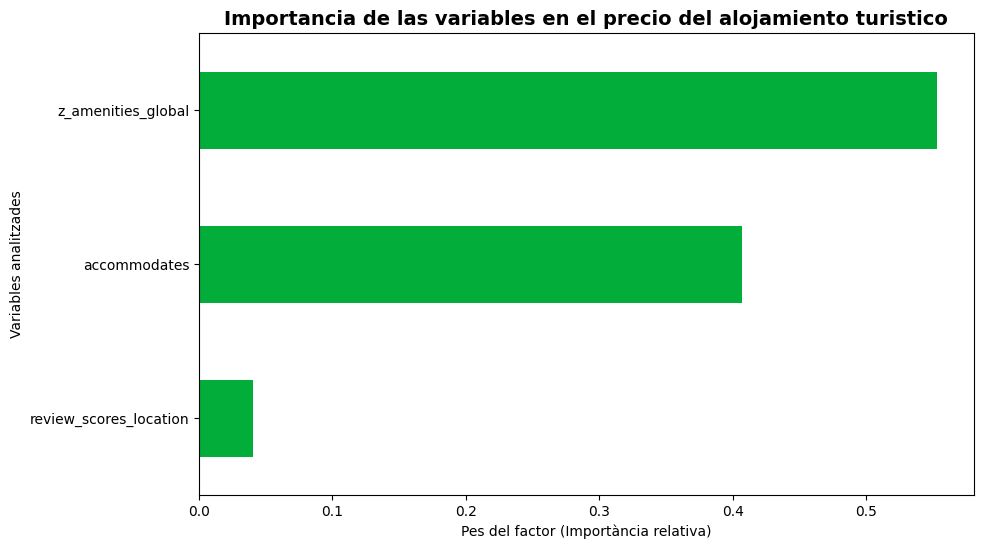

In [ ]:
# Creación y entrenamiento del modelo de árbol de decisión
arbol = RandomForestRegressor(n_estimators=100, random_state=42)
arbol.fit(XX_train, yy_train)

# 4. Creem el gràfic d'importància
importances = pd.Series(arbol.feature_importances_, index=tres_variables).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#02AD3A') # El teu verd OK

plt.title('Importancia de las variables en el precio del alojamiento turistico', fontsize=14, fontweight='bold')
plt.xlabel('Pes del factor (Importància relativa)')
plt.ylabel('Variables analitzades')

plt.show()

In [94]:
# Hacer predicciones sobre el conjunto de prueba
y_predLineal = modelo_Lineal.predict(XX_test)
y_predForest = modelo_Forest.predict(XX_test)

In [95]:
tres_variables = ['accommodates','review_scores_location','z_amenities_global']

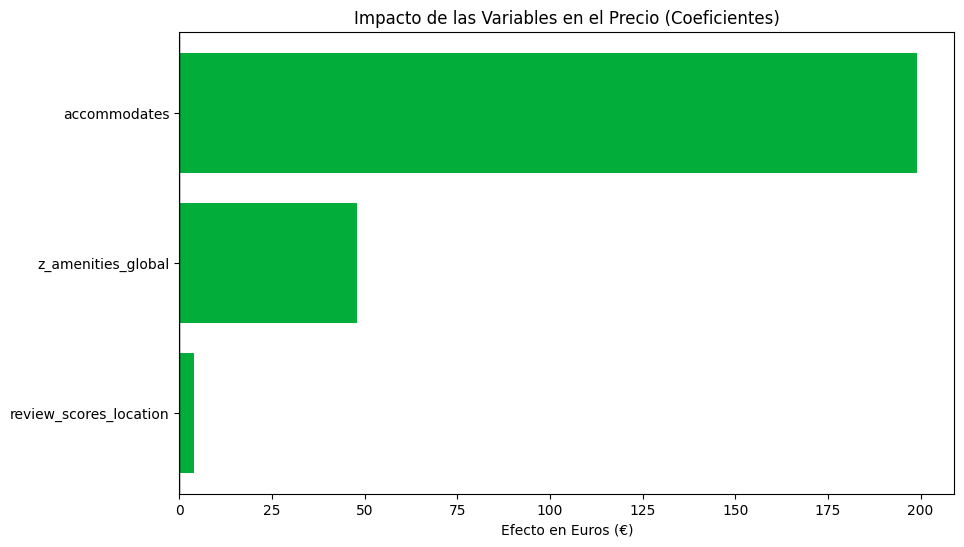

In [96]:
tres_variables = ['accommodates','review_scores_location','z_amenities_global']
coefs = modelo_Lineal.coef_

df_coefs = pd.DataFrame({'Variable': tres_variables, 'Coeficiente': coefs})
df_coefs = df_coefs.sort_values(by='Coeficiente', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#A80000' if x < 0 else '#02AD3A' for x in df_coefs['Coeficiente']]
plt.barh(df_coefs['Variable'], df_coefs['Coeficiente'], color=colors)
plt.axvline(0, color='black', linestyle='-', linewidth=1)
plt.title('Impacto de las Variables en el Precio (Coeficientes)')
plt.xlabel('Efecto en Euros (€)')
plt.show()

In [97]:
# Crear y entrenar el modelo
modelo_Lineal = LinearRegression().fit(XX_train, yy_train)
modelo_Forest = RandomForestClassifier().fit(XX_train, yy_train)

In [ ]:
# Hacer predicciones sobre el conjunto de prueba
y_predLineal = modelo_Lineal.predict(XX_test)
y_predForest = modelo_Forest.predict(XX_test)

In [99]:
# Comapramos predicciones de valore sreales y prueba
accuracy = accuracy_score(yy_test, y_predForest)
print("Accuracy:", accuracy)

Accuracy: 0.025210084033613446


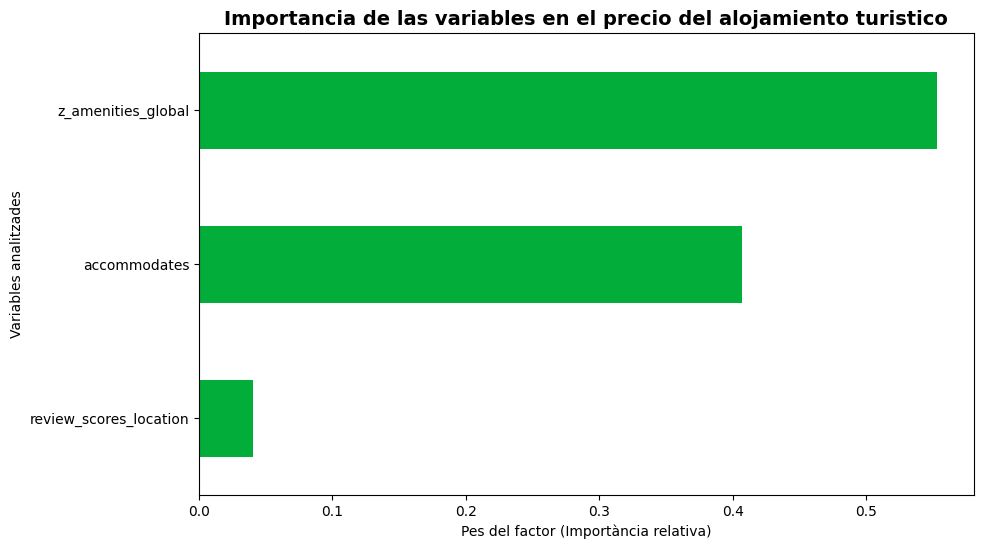

In [100]:
# Creación y entrenamiento del modelo de árbol de decisión
arbol = RandomForestRegressor(n_estimators=100, random_state=42)
arbol.fit(XX_train, yy_train)

# 4. Creem el gràfic d'importància
importances = pd.Series(arbol.feature_importances_, index=tres_variables).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#02AD3A') # El teu verd OK

plt.title('Importancia de las variables en el precio del alojamiento turistico', fontsize=14, fontweight='bold')
plt.xlabel('Pes del factor (Importància relativa)')
plt.ylabel('Variables analitzades')

plt.show()

In [102]:
# Convertimos la serie en un DataFrame
df_pesos = importances.to_frame(name='Peso_Relativo').sort_values(by='Peso_Relativo', ascending=False)

# # Añadimos una columna con el porcentaje para que sea más legible
# df_pesos['Porcentaje'] = (df_pesos['Peso_Relativo'] * 100).round(2).astype(str) + '%'

print(df_pesos)

                        Peso_Relativo
z_amenities_global           0.552850
accommodates                 0.406752
review_scores_location       0.040398
